# **AST Transfer Learning + Progressive Unfreezing + SpecAugment**

## Modello: Audio Spectrogram Transformer (AST) pre-addestrato su AudioSet

**Novita rispetto alla versione BiGRU-Attention-L2:**
- **Transfer Learning**: Backbone AST (`MIT/ast-finetuned-audioset-10-10-0.4593`) pre-addestrato su 527 classi AudioSet
- **Fine-Tuning con Progressive Unfreezing**: backbone scongelato progressivamente in 4 fasi per evitare catastrophic forgetting
- **SpecAugment**: mascheramento casuale di bande di frequenza e frame temporali per regolarizzare il training
- Il resto del pipeline (data augmentation, dataset RAVDESS, checkpoint) rimane invariato


# **Importing libraries**


In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
import librosa
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset
import glob
import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd
%matplotlib inline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# ---- NUOVE LIBRERIE per Transfer Learning ----
# pip install transformers  (su Kaggle e gia disponibile)
from transformers import ASTFeatureExtractor, ASTModel

print('Librerie caricate con successo.')


Librerie caricate con successo.


# Get Computational Device


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


Dispositivo: cuda


# Importing the Dataset


In [3]:
DATASET_PATH = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"
emotion_map = {
    0: "neutral", 1: "calm", 2: "happy", 3: "sad",
    4: "angry",   5: "fearful", 6: "disgust", 7: "surprised"
}


# Data Augmentation

Le stesse tecniche della versione precedente: Time Stretching, Pitch Shifting, Dynamic Range Compression e Background Noise Injection.

**SpecAugment** viene applicato separatamente sullo spettrogramma (vedi sezione apposita).


In [4]:
def apply_time_stretch(wav, rate):
    return librosa.effects.time_stretch(y=wav, rate=rate)

def apply_pitch_shift(wav, sr, n_steps):
    return librosa.effects.pitch_shift(y=wav, sr=sr, n_steps=n_steps)

def apply_bg_noise(wav):
    noise  = np.random.randn(*wav.shape)
    weight = np.random.uniform(0.10, 0.50)
    return wav + weight * noise

def apply_drc_basic(wav):
    return np.sign(wav) * np.log1p(100 * np.abs(wav)) / np.log1p(100)


# SpecAugment

SpecAugment ([Park et al., 2019](https://arxiv.org/abs/1904.08779)) applica maschere casuali sul log-mel spettrogramma **solo durante il training**.

Vengono applicati:
- **Frequency Masking**: maschera fino a `F=27` bande di frequenza consecutive
- **Time Masking** (x2): maschera fino a `T=100` frame temporali consecutivi

Il modulo lavora con tensori di shape `(B, time, freq)` come output di `ASTFeatureExtractor`.


In [5]:
class SpecAugment(nn.Module):
    """
    Applica SpecAugment a batch di log-mel feature di shape (B, time, freq).
    Compatibile con l'output di ASTFeatureExtractor.
    """
    def __init__(self, freq_mask_param: int = 27, time_mask_param: int = 100,
                 n_time_masks: int = 2, iid_masks: bool = True):
        super().__init__()
        self.freq_masking  = T.FrequencyMasking(freq_mask_param=freq_mask_param)
        self.time_maskings = nn.ModuleList([
            T.TimeMasking(time_mask_param=time_mask_param, iid_masks=iid_masks)
            for _ in range(n_time_masks)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, time, freq) -> trasponi per torchaudio -> (B, freq, time)
        x = x.transpose(1, 2)
        x = self.freq_masking(x)
        for tm in self.time_maskings:
            x = tm(x)
        x = x.transpose(1, 2)   # torna (B, time, freq)
        return x


spec_augment = SpecAugment(
    freq_mask_param=27,
    time_mask_param=100,
    n_time_masks=2,
    iid_masks=True
).to(device)

print('SpecAugment pronto:', spec_augment)


SpecAugment pronto: SpecAugment(
  (freq_masking): FrequencyMasking()
  (time_maskings): ModuleList(
    (0-1): 2 x TimeMasking()
  )
)


# Creazione del Dataset aumentato su disco
*(Cella da eseguire una sola volta)*


In [6]:
from transformers import ASTFeatureExtractor

AST_MODEL_NAME = 'MIT/ast-finetuned-audioset-10-10-0.4593'

feature_extractor = ASTFeatureExtractor.from_pretrained(
    AST_MODEL_NAME,
    max_length=1024,      
    num_mel_bins=128,     
    do_normalize=True,    
)
print(f'Feature extractor pronto. Estraiamo le feature PRIMA del training.')

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Feature extractor pronto. Estraiamo le feature PRIMA del training.


In [7]:
os.makedirs('/kaggle/working/processed_data/train', exist_ok=True)
os.makedirs('/kaggle/working/processed_data/val',   exist_ok=True)
os.makedirs('/kaggle/working/processed_data/test',  exist_ok=True)

def generate_augmented_dataset_ondisk(root_dir=DATASET_PATH):
    counters  = {'train': 0, 'val': 0, 'test': 0}
    all_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.endswith('.wav'):
                all_files.append(os.path.join(dirpath, f))

    for file_path in tqdm(all_files, desc='Estrazione AST e Salvataggio'):
        filename = os.path.basename(file_path)
        parts    = filename.replace('.wav', '').split('-')
        if len(parts) != 7: continue

        emotion_label = int(parts[2]) - 1
        speaker_id    = int(parts[6])

        waveform, sample_rate = torchaudio.load(file_path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sample_rate != 16000:
            resampler   = T.Resample(orig_freq=sample_rate, new_freq=16000)
            waveform    = resampler(waveform)
            sample_rate = 16000

        wav_np         = waveform.squeeze().numpy()
        wav_trimmed, _ = librosa.effects.trim(wav_np, top_db=30)
        wav_orig       = librosa.util.normalize(wav_trimmed)

        subset = 'train' if speaker_id <= 18 else ('val' if 19 <= speaker_id <= 22 else 'test')

        def save_file(wav_data, subset_name):
            # Calcola lo spettrogramma QUI, una volta per tutte
            inputs = feature_extractor(
                wav_data, 
                sampling_rate=16000, 
                return_tensors='pt', 
                padding='max_length', 
                max_length=1024
            )
            feats = inputs['input_values'].squeeze(0) # shape: (1024, 128)
            
            path = f'/kaggle/working/processed_data/{subset_name}/sample_{counters[subset_name]}.pt'
            torch.save((feats, emotion_label, speaker_id), path)
            counters[subset_name] += 1

        # Salva originale
        save_file(wav_orig, subset)
        
        # Augmentation ridotta (solo per training) per velocizzare i run
        if subset == 'train':
            save_file(apply_time_stretch(wav_orig, 0.93), 'train') # 1 solo stretch
            save_file(apply_pitch_shift(wav_orig, sample_rate, 2), 'train') # 1 solo pitch shift
            save_file(apply_bg_noise(wav_orig), 'train') # 1 solo noise
            save_file(apply_drc_basic(wav_orig), 'train')

    print('\nSalvataggio completato!')
    print(f"Train: {counters['train']}  Val: {counters['val']}  Test: {counters['test']}")

generate_augmented_dataset_ondisk()

Estrazione AST e Salvataggio: 100%|██████████| 2880/2880 [02:56<00:00, 16.28it/s]


Salvataggio completato!
Train: 10800  Val: 480  Test: 240


# Dataset per il Training


In [8]:
class FastRavdessDataset(Dataset):
    def __init__(self, folder_path):
        self.file_paths = glob.glob(f'{folder_path}/*.pt')

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Carica direttamente le feature log-mel
        feats, emotion_label, speaker_id = torch.load(self.file_paths[idx], weights_only=False)
        label_tensor = torch.tensor(emotion_label, dtype=torch.long)
        return feats, label_tensor

train_dataset = FastRavdessDataset('/kaggle/working/processed_data/train')
val_dataset   = FastRavdessDataset('/kaggle/working/processed_data/val')
test_dataset  = FastRavdessDataset('/kaggle/working/processed_data/test')

BATCH_SIZE = 16 

def collate_fn_train(batch):
    feats, targets = zip(*batch)
    # Creiamo i tensori, ma li lasciamo sulla CPU
    feats = torch.stack(feats)
    targets = torch.stack(targets)
    return feats, targets

def collate_fn_eval(batch):
    feats, targets = zip(*batch)
    feats = torch.stack(feats)
    targets = torch.stack(targets)
    return feats, targets

num_workers = 2 if device.type == 'cuda' else 0

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_train, num_workers=num_workers)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_eval, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_eval, num_workers=num_workers)

print(f'Batch train: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}')

Batch train: 675  |  Val: 30  |  Test: 15


# Verifica Visiva della Data Augmentation


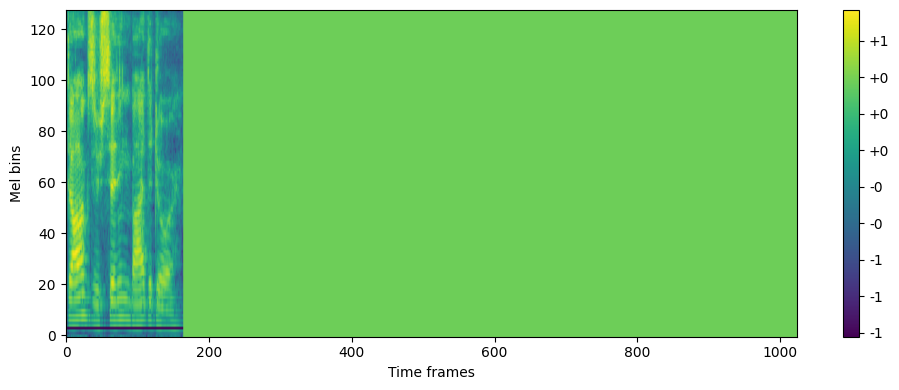

In [9]:
idx = 3
feats, label = train_dataset[idx]

plt.figure(figsize=(10, 4))
# feats ha shape (time, freq), trasponiamo per la visualizzazione standard
plt.imshow(feats.squeeze().T.numpy(), aspect='auto', origin='lower', cmap='viridis')
plt.ylabel('Mel bins')
plt.xlabel('Time frames')
plt.colorbar(format='%+2.0f')
plt.tight_layout()
plt.show()

# Label Utilities


In [10]:
inverse_emotion_map = {v.lower(): k for k, v in emotion_map.items()}

def label_to_index(word):
    return torch.tensor(inverse_emotion_map[word.lower()])

def index_to_label(index):
    if torch.is_tensor(index): index = index.item()
    return emotion_map.get(index, f'Unknown ({index})')

w = 'Calm'
print(f'{w} -> {label_to_index(w)} -> {index_to_label(label_to_index(w))}')


Calm -> 1 -> calm


# Modello: AST Transfer Learning

Il backbone `ASTModel` (12 layer Transformer, hidden=768) e pre-addestrato su AudioSet. Sopra viene innestata una **testa di classificazione** per le 8 emozioni RAVDESS.

**Architettura della testa:**
```
CLS token -> LayerNorm -> Dropout(0.3) -> Linear(768->256) -> GELU -> Dropout(0.2) -> Linear(256->8)
```


In [11]:
class ASTEmotionClassifier(nn.Module):
    """
    Transfer Learning con Audio Spectrogram Transformer (AST).
    Solo il CLS token (outputs.last_hidden_state[:, 0, :]) viene
    passato alla testa di classificazione.
    """
    def __init__(self, num_classes: int = 8,
                 pretrained_model: str = 'MIT/ast-finetuned-audioset-10-10-0.4593',
                 head_dropout_1: float = 0.3,
                 head_dropout_2: float = 0.2):
        super().__init__()
        self.ast        = ASTModel.from_pretrained(pretrained_model)
        hidden_size     = self.ast.config.hidden_size   # 768

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(head_dropout_1),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(head_dropout_2),
            nn.Linear(256, num_classes),
        )

        # Inizializzazione Xavier per la testa
        for module in self.classifier.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        # input_values: (B, time, mel_bins)
        outputs    = self.ast(input_values=input_values)
        cls_output = outputs.last_hidden_state[:, 0, :]   # (B, 768)
        return self.classifier(cls_output)                # (B, num_classes)


# Istanza e sanity check
model = ASTEmotionClassifier(num_classes=8, pretrained_model=AST_MODEL_NAME).to(device)

_dummy_in = torch.zeros(2, 1024, 128).to(device)
with torch.no_grad():
    _out = model(_dummy_in)
print(f'Shape check -> input: {list(_dummy_in.shape)}  output: {list(_out.shape)}')
assert _out.shape == (2, 8)
print('Forward pass OK')

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametri totali:       {total_params:,}')
print(f'Parametri addestrabili: {trainable_params:,}')


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape check -> input: [2, 1024, 128]  output: [2, 8]
Forward pass OK
Parametri totali:       86,387,720
Parametri addestrabili: 86,387,720


# Progressive Unfreezing

**Problema**: fare fine-tuning di tutti i parametri fin dal primo epoch causa *catastrophic forgetting*: i pesi pre-addestrati vengono sovrascritti prima che la testa converga.

**Soluzione - 4 fasi progressive:**

| Fase | Epoche | Layers scongelati | LR |
|------|--------|-------------------|----|
| 1 - Warmup | 1-5 | Solo testa | 1e-3 |
| 2 - Fine-tuning leggero | 6-10 | Testa + top 4 encoder + LayerNorm | 5e-5 |
| 3 - Fine-tuning moderato | 11-20 | Testa + top 8 encoder + LayerNorm | 2e-5 |
| 4 - Fine-tuning completo | 21-30 | Tutto il modello | 1e-5 |


In [12]:
# ────────────────────────────────────────────────────────────
# Utilita per il Progressive Unfreezing
# ────────────────────────────────────────────────────────────

def freeze_backbone(model):
    """Congela TUTTO il backbone AST; solo la testa rimane addestrabile."""
    for param in model.ast.parameters():
        param.requires_grad = False


def unfreeze_top_n_encoder_layers(model, n: int):
    """
    Scongela gli ultimi n layer dell'encoder + il LayerNorm finale.
    I layer dell'encoder AST sono in model.ast.encoder.layer[0..11].
    """
    for param in model.ast.layernorm.parameters():
        param.requires_grad = True
    total_layers = len(model.ast.encoder.layer)   # 12 per AST-base
    start_idx    = max(0, total_layers - n)
    for i in range(start_idx, total_layers):
        for param in model.ast.encoder.layer[i].parameters():
            param.requires_grad = True


def unfreeze_all(model):
    """Scongela l'intero modello (backbone + testa)."""
    for param in model.parameters():
        param.requires_grad = True


def count_trainable(model) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ────────────────────────────────────────────────────────────
# Configurazione DEFINITIVA per la valutazione (30 epoche)
# ────────────────────────────────────────────────────────────
PHASES = [
    # (epoch_start, epoch_end, unfreeze_fn,                              lr)
    (1,  5,  lambda m: freeze_backbone(m),                             1e-3), # Solo la testa
    (6,  10, lambda m: unfreeze_top_n_encoder_layers(m, n=4),          5e-5), # Testa + 4 layer
    (11, 20, lambda m: unfreeze_top_n_encoder_layers(m, n=8),          2e-5), # Testa + 8 layer
    (21, 30, lambda m: unfreeze_all(m),                                1e-5), # Tutto il modello
]
TOTAL_EPOCHS = PHASES[-1][1]   # 30

print(f'Epoche totali previste : {TOTAL_EPOCHS}')

print(f'Layer encoder AST      : {len(model.ast.encoder.layer)}')


Epoche totali previste : 30
Layer encoder AST      : 12


# Funzioni generiche di training, test e valutazione


In [13]:
scaler = torch.cuda.amp.GradScaler()

def train_epoch(model, optimizer, criterion, epoch, log_interval=20):
    model.train()
    spec_augment.train()    
    running_loss = 0.0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        # 1. Spostiamo i dati sulla GPU QUI, nel main process
        data, target = data.to(device), target.to(device)
        
        # 2. Applichiamo SpecAugment sulla GPU
        data = spec_augment(data)

        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            output = model(data)
            loss   = criterion(output, target)
            
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        if batch_idx % log_interval == 0:
            print(f'  Epoch {epoch} [{batch_idx * len(data):>5}/{len(train_loader.dataset)}]  Loss: {loss.item():.4f}')
            
    return running_loss / len(train_loader)


@torch.no_grad()
def evaluate(model, loader, criterion, split='Val'):
    model.eval()
    spec_augment.eval()    
    total_loss, correct = 0.0, 0
    
    for data, target in loader:
        # Spostiamo i dati sulla GPU
        data, target = data.to(device), target.to(device)
        
        output      = model(data)
        total_loss += criterion(output, target).item()
        correct    += output.argmax(dim=-1).eq(target).sum().item()
        
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / len(loader.dataset)
    print(f'  [{split}] Loss: {avg_loss:.4f}  Accuracy: {correct}/{len(loader.dataset)} ({accuracy:.1f}%)')
    return accuracy, avg_loss


@torch.no_grad()
def evaluate_model(model, loader, split='Test'):
    """Valutazione completa: accuracy, F1 macro, confusion matrix."""
    model.eval()
    spec_augment.eval()
    all_preds, all_targets = [], []
    
    for data, target in loader:
        # Spostiamo i dati sulla GPU
        data, target = data.to(device), target.to(device)
        
        preds = model(data).argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

    acc     = accuracy_score(all_targets, all_preds)
    f1      = f1_score(all_targets, all_preds, average='macro')
    cm      = confusion_matrix(all_targets, all_preds)
    classes = [emotion_map[i] for i in range(len(cm))]

    print('\n' + '='*50)
    print(f'RISULTATI FINALI --- {split} SET')
    print('='*50)
    print(f'Accuracy  : {acc*100:.2f}%')
    print(f'F1 (macro): {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(all_targets, all_preds, target_names=classes))

    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predizione')
    plt.ylabel('Reale')
    plt.title(f'Confusion Matrix --- {split}')
    plt.tight_layout()
    plt.show()
    return acc, f1, cm

/tmp/ipykernel_55/3425112234.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


# Training con Progressive Unfreezing

Il loop scorre le 4 fasi definite in `PHASES`. All'inizio di ogni fase:
1. Viene chiamata la funzione di unfreeze corrispondente.
2. Viene **ricreato l'optimizer** (AdamW) con i soli parametri trainable, evitando state AdamW stantii.
3. Uno scheduler `CosineAnnealingLR` governa il decadimento del LR all'interno della fase.


In [ ]:
import torch, torch.nn as nn, torch.optim as optim
from tqdm import tqdm

# Reinizializza il modello (commenta se usi resume training sotto)
model = ASTEmotionClassifier(num_classes=8, pretrained_model=AST_MODEL_NAME).to(device)

criterion       = nn.CrossEntropyLoss(label_smoothing=0.1)
history         = {'train_loss': [], 'val_loss': [], 'val_acc': []}
LOG_INTERVAL    = 20
BEST_VAL_ACC    = 0.0
CHECKPOINT_PATH = '/kaggle/working/ast_best.pth'

print(f'Avvio training --- {TOTAL_EPOCHS} epoche su {device}')
print('=' * 60)

current_phase_idx = -1
optimizer = scheduler = None

for epoch in range(1, TOTAL_EPOCHS + 1):

    # -- Controlla se si e entrati in una nuova fase --------
    for phase_idx, (ep_start, ep_end, unfreeze_fn, lr) in enumerate(PHASES):
        if epoch == ep_start and phase_idx != current_phase_idx:
            current_phase_idx = phase_idx
            unfreeze_fn(model)
            trainable = [p for p in model.parameters() if p.requires_grad]
            optimizer = optim.AdamW(trainable, lr=lr, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=(ep_end - ep_start + 1)
            )
            print(f'\n>>> FASE {phase_idx+1} avviata (epoch {ep_start}-{ep_end})')
            print(f'    LR={lr}  |  Parametri addestrabili: {count_trainable(model):,}')
            print('=' * 60)
            break

    # -- Training ------------------------------------------
    with tqdm(total=1.0, desc=f'Epoch {epoch:02d}/{TOTAL_EPOCHS}', leave=True) as pbar:
        train_loss        = train_epoch(model, optimizer, criterion, epoch, LOG_INTERVAL)
        val_acc, val_loss = evaluate(model, val_loader, criterion, split='Val')
        pbar.update(1.0)

    scheduler.step()
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # -- Salva il miglior checkpoint -----------------------
    if val_acc > BEST_VAL_ACC:
        BEST_VAL_ACC = val_acc
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc'             : val_acc,
            'history'             : history,
        }, CHECKPOINT_PATH)
        print(f'  > Nuovo best checkpoint salvato (val_acc={val_acc:.1f}%)')

print(f'\nTraining completato. Best val accuracy: {BEST_VAL_ACC:.1f}%')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Avvio training --- 30 epoche su cuda

>>> FASE 1 avviata (epoch 1-5)
    LR=0.001  |  Parametri addestrabili: 200,456


Epoch 01/30:   0%|          | 0/1.0 [00:00<?, ?it/s]/tmp/ipykernel_55/3425112234.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Epoch 1 [    0/10800]  Loss: 3.0430
  Epoch 1 [  320/10800]  Loss: 2.6519
  Epoch 1 [  640/10800]  Loss: 2.5695
  Epoch 1 [  960/10800]  Loss: 2.2553
  Epoch 1 [ 1280/10800]  Loss: 1.9196
  Epoch 1 [ 1600/10800]  Loss: 1.8449
  Epoch 1 [ 1920/10800]  Loss: 1.8064
  Epoch 1 [ 2240/10800]  Loss: 1.8301
  Epoch 1 [ 2560/10800]  Loss: 2.1428
  Epoch 1 [ 2880/10800]  Loss: 2.0637
  Epoch 1 [ 3200/10800]  Loss: 2.3220
  Epoch 1 [ 3520/10800]  Loss: 1.9335
  Epoch 1 [ 3840/10800]  Loss: 1.9916
  Epoch 1 [ 4160/10800]  Loss: 1.7915
  Epoch 1 [ 4480/10800]  Loss: 1.8275
  Epoch 1 [ 4800/10800]  Loss: 1.8692
  Epoch 1 [ 5120/10800]  Loss: 1.8432
  Epoch 1 [ 5440/10800]  Loss: 1.6576
  Epoch 1 [ 5760/10800]  Loss: 1.6724
  Epoch 1 [ 6080/10800]  Loss: 1.6979
  Epoch 1 [ 6400/10800]  Loss: 1.7404
  Epoch 1 [ 6720/10800]  Loss: 2.0517
  Epoch 1 [ 7040/10800]  Loss: 1.6147
  Epoch 1 [ 7360/10800]  Loss: 1.7825
  Epoch 1 [ 7680/10800]  Loss: 1.6307
  Epoch 1 [ 8000/10800]  Loss: 1.6726
  Epoch 1 [ 

...

  Epoch 24 [    0/10800]  Loss: 0.7335
  Epoch 24 [  320/10800]  Loss: 0.6694
  Epoch 24 [  640/10800]  Loss: 0.6654
  Epoch 24 [  960/10800]  Loss: 0.5829
  Epoch 24 [ 1280/10800]  Loss: 0.5396
  Epoch 24 [ 1600/10800]  Loss: 1.0358
  Epoch 24 [ 1920/10800]  Loss: 0.7842
  Epoch 24 [ 2240/10800]  Loss: 0.5197
  Epoch 24 [ 2560/10800]  Loss: 0.4942
  Epoch 24 [ 2880/10800]  Loss: 0.8647
  Epoch 24 [ 3200/10800]  Loss: 0.7210
  Epoch 24 [ 3520/10800]  Loss: 0.5798
  Epoch 24 [ 3840/10800]  Loss: 0.4972
  Epoch 24 [ 4160/10800]  Loss: 0.5108
  Epoch 24 [ 4480/10800]  Loss: 0.7666
  Epoch 24 [ 4800/10800]  Loss: 0.4968
  Epoch 24 [ 5120/10800]  Loss: 0.5854
  Epoch 24 [ 5440/10800]  Loss: 0.6989
  Epoch 24 [ 5760/10800]  Loss: 0.5410
  Epoch 24 [ 6080/10800]  Loss: 0.7723
  Epoch 24 [ 6400/10800]  Loss: 0.5198
  Epoch 24 [ 6720/10800]  Loss: 0.7679
  Epoch 24 [ 7040/10800]  Loss: 0.5228
  Epoch 24 [ 7360/10800]  Loss: 0.5823
  Epoch 24 [ 7680/10800]  Loss: 0.5085
  Epoch 24 [ 8000/10800] 

Epoch 24/30: 100%|██████████| 1.0/1.0 [13:17<00:00, 797.16s/it]


  [Val] Loss: 1.4416  Accuracy: 320/480 (66.7%)


Epoch 25/30:   0%|          | 0/1.0 [00:00<?, ?it/s]

  Epoch 25 [    0/10800]  Loss: 0.7846
  Epoch 25 [  320/10800]  Loss: 0.5714
  Epoch 25 [  640/10800]  Loss: 0.5011
  Epoch 25 [  960/10800]  Loss: 0.5109
  Epoch 25 [ 1280/10800]  Loss: 0.5263
  Epoch 25 [ 1600/10800]  Loss: 0.5279
  Epoch 25 [ 1920/10800]  Loss: 0.5128
  Epoch 25 [ 2240/10800]  Loss: 0.4992
  Epoch 25 [ 2560/10800]  Loss: 0.5786
  Epoch 25 [ 2880/10800]  Loss: 0.5144
  Epoch 25 [ 3200/10800]  Loss: 0.4943
  Epoch 25 [ 3520/10800]  Loss: 0.4974
  Epoch 25 [ 3840/10800]  Loss: 0.4941
  Epoch 25 [ 4160/10800]  Loss: 0.6904
  Epoch 25 [ 4480/10800]  Loss: 0.5035
  Epoch 25 [ 4800/10800]  Loss: 0.7671
  Epoch 25 [ 5120/10800]  Loss: 0.5312
  Epoch 25 [ 5440/10800]  Loss: 0.5602
  Epoch 25 [ 5760/10800]  Loss: 0.5219
  Epoch 25 [ 6080/10800]  Loss: 0.4916
  Epoch 25 [ 6400/10800]  Loss: 0.5666
  Epoch 25 [ 6720/10800]  Loss: 0.5169
  Epoch 25 [ 7040/10800]  Loss: 0.6593
  Epoch 25 [ 7360/10800]  Loss: 0.6753
  Epoch 25 [ 7680/10800]  Loss: 0.5751


# Curve di Training


In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_range, history['val_acc'], color='green', label='Val Accuracy')
axes[1].axhline(y=BEST_VAL_ACC, color='red', linestyle='--', label=f'Best = {BEST_VAL_ACC:.1f}%')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

colors = ['#f0e68c', '#b0e0e6', '#98fb98', '#dda0dd']
for ax in axes:
    for i, (es, ee, _, _) in enumerate(PHASES):
        ax.axvspan(es - 0.5, ee + 0.5, alpha=0.15, color=colors[i])

plt.tight_layout(); plt.show()


<h1>RESUME TRAINING</h1>
<h2>Usa un file .pth per riprendere il training. Commenta questo blocco altrimenti.</h2>


In [ ]:

import torch, torch.nn as nn, torch.optim as optim
from tqdm import tqdm

CHECKPOINT_RESUME_PATH = '/kaggle/input/datasets/youruser/ast_best.pth'

model      = ASTEmotionClassifier(num_classes=8, pretrained_model=AST_MODEL_NAME).to(device)
checkpoint = torch.load(CHECKPOINT_RESUME_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
history      = checkpoint.get('history', {'train_loss': [], 'val_loss': [], 'val_acc': []})
start_epoch  = checkpoint['epoch'] + 1
BEST_VAL_ACC = checkpoint.get('val_acc', 0.0)
criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)
print(f"Ripresa training dall'epoch {start_epoch}  |  Best val acc: {BEST_VAL_ACC:.1f}%")

current_phase_idx = -1
optimizer = scheduler = None

for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    for phase_idx, (ep_start, ep_end, unfreeze_fn, lr) in enumerate(PHASES):
        if epoch >= ep_start and phase_idx != current_phase_idx and epoch <= ep_end:
            current_phase_idx = phase_idx
            unfreeze_fn(model)
            trainable = [p for p in model.parameters() if p.requires_grad]
            optimizer = optim.AdamW(trainable, lr=lr, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=(ep_end - ep_start + 1)
            )
            if checkpoint.get('optimizer_state_dict') and epoch == start_epoch:
                try:
                    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                except Exception as e:
                    print(f'Impossibile ripristinare optimizer/scheduler: {e}')
            print(f'\n>>> Fase {phase_idx+1} attiva --- LR={lr}  Params: {count_trainable(model):,}')
            break

    with tqdm(total=1.0, desc=f'Epoch {epoch:02d}/{TOTAL_EPOCHS}') as pbar:
        train_loss        = train_epoch(model, optimizer, criterion, epoch, LOG_INTERVAL)
        val_acc, val_loss = evaluate(model, val_loader, criterion, split='Val')
        pbar.update(1.0)

    scheduler.step()
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > BEST_VAL_ACC:
        BEST_VAL_ACC = val_acc
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc, 'history': history,
        }, CHECKPOINT_PATH)
        print(f'  > Nuovo best salvato (val_acc={val_acc:.1f}%)')

print(f'Resume completato. Best val accuracy: {BEST_VAL_ACC:.1f}%')


<h1>SALVA STATO TRAINING</h1>


In [ ]:
'''
current_epoch = 10   # modifica con l'epoch corrente
save_path     = '/kaggle/working/ast_manual_checkpoint.pth'

torch.save({
    'epoch'               : current_epoch,
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'val_acc'             : BEST_VAL_ACC,
    'history'             : history,
}, save_path)
print(f'Checkpoint salvato: {save_path}')
'''


# Valutazione Finale sul Test Set


In [ ]:
# Carica il miglior checkpoint prima della valutazione finale
best_ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(best_ckpt['model_state_dict'])
print(f"Caricato checkpoint epoch {best_ckpt['epoch']} (val_acc={best_ckpt['val_acc']:.1f}%)")

acc, f1, cm = evaluate_model(model, test_loader, split='Test')
